#  Importing the required packages for the pre-data analysis

In [1]:
# NutriClass - Food Classification
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Loading the Dataset

In [2]:
df = pd.read_csv('synthetic_food_dataset_imbalanced.csv')

In [3]:
df.head(5)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [4]:
df.tail(5)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
31695,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,81.784216,120.293342,lunch,fried,True,True,Banana
31696,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,192.062481,lunch,raw,False,False,Pizza
31697,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,197.318164,breakfast,grilled,False,False,Pizza
31698,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,152.072098,dinner,grilled,False,False,Pasta
31699,203.952826,5.322650,13.419346,26.686660,14.645211,0.295026,62.468736,38.417093,57.987511,51.156165,113.912626,breakfast,grilled,False,True,Ice Cream


# Checking dataset shape

In [5]:
df.shape

(31700, 16)

# Checking column names

In [6]:
print(df.columns.tolist())

['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']


# Statistical summary

In [7]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


# Dataset information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

# Missing values

In [11]:
df.isna().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

# Duplicate rows

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


# Identifing the target column

In [13]:
print("Target Column:", "Food_Name")
print("Number of Food Categories:", df["Food_Name"].nunique())

Target Column: Food_Name
Number of Food Categories: 10


In [14]:
df["Food_Name"].value_counts().head(20)

Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64

# Visualize Class Distribution

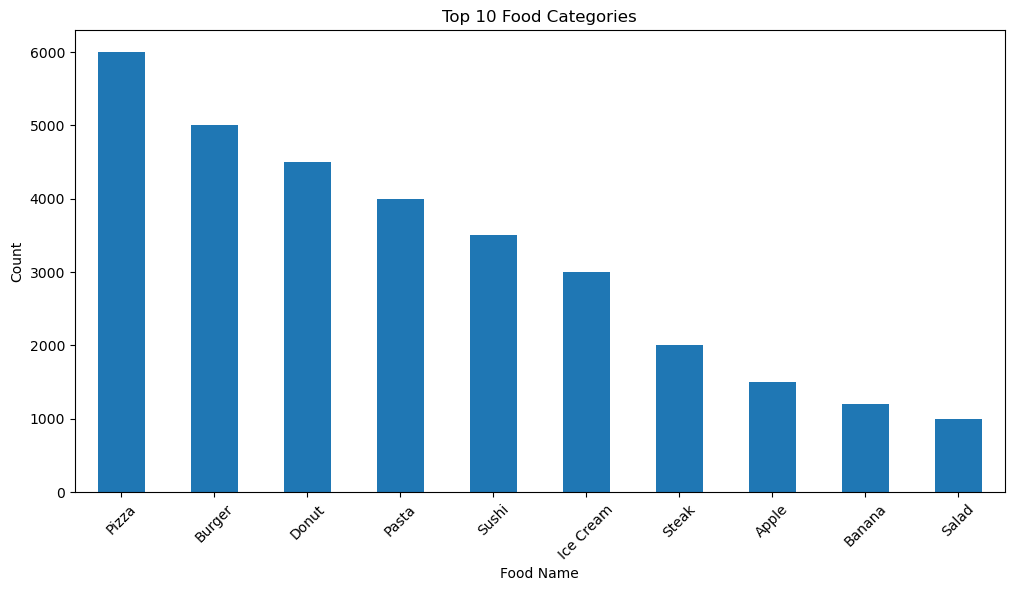

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df["Food_Name"].value_counts().head(20).plot(kind="bar")
plt.title("Top 10 Food Categories")
plt.xlabel("Food Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Class imbalance has been identified in the dataset, with class 6 dominating and class 7 severely underrepresented. 

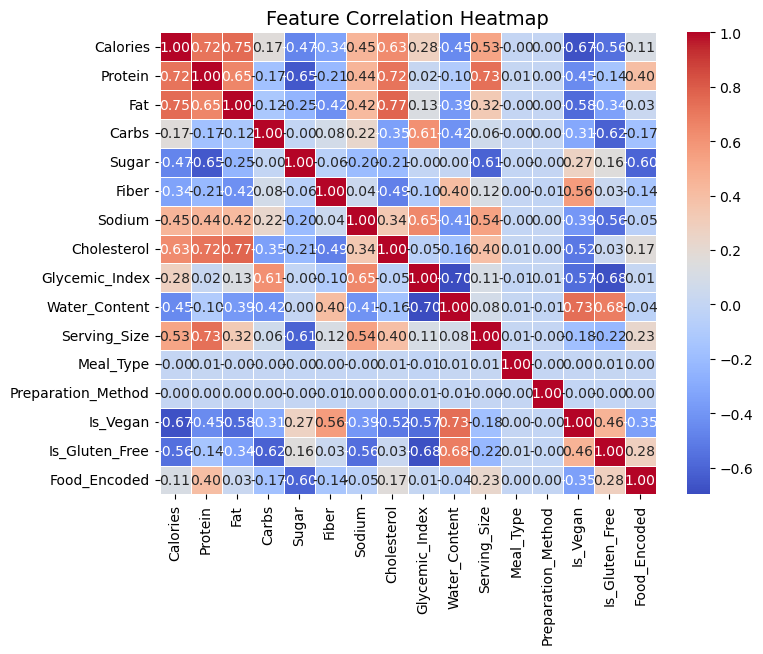

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap with annotations
plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    cmap='coolwarm', 
    annot=True,        # show correlation values
    fmt=".2f",         # format to 2 decimal places
    linewidths=0.5     # thin lines between cells
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()


# Data Preprocessing

### Removing Duplicate Rows

In [17]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (31387, 16)


### Handling Missing Values

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols


['Calories',
 'Protein',
 'Fat',
 'Carbs',
 'Sugar',
 'Fiber',
 'Sodium',
 'Cholesterol',
 'Glycemic_Index',
 'Water_Content',
 'Serving_Size']

In [19]:
# Missing values
imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14560\1399886570.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = imputer.fit_transform(df[num_cols])


### Sum of missing values entries after imputation

In [20]:
df.isna().sum()

Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64

### Outlier detection and handling

In [21]:
# Detect outliers BEFORE capping
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    count = mask.sum()
    values = df.loc[mask, col].tolist()
    
    outlier_summary.append({
        "Column": col,
        "Outlier_Count": count,
        "Outlier_Values": values
    })

# Convert to DataFrame for neat table
outlier_table = pd.DataFrame(outlier_summary)
print(outlier_table)

            Column  Outlier_Count  \
0         Calories             94   
1          Protein            859   
2              Fat            808   
3            Carbs           2730   
4            Sugar             84   
5            Fiber            480   
6           Sodium             84   
7      Cholesterol           2046   
8   Glycemic_Index           3125   
9    Water_Content           3326   
10    Serving_Size             84   

                                       Outlier_Values  
0   [1289.9567634777725, 1289.9567634777725, 1289....  
1   [28.25227073309663, 28.265491326579717, 29.630...  
2   [28.55727275390807, 30.05368654376032, 27.6683...  
3   [0.0, 0.3168365092460115, 0.5348856358484709, ...  
4   [78.54816154798785, 78.54816154798785, 78.5481...  
5   [6.083345249235419, 18.891993390584062, 5.5344...  
6   [2724.2368458617398, 2724.2368458617398, 2724....  
7   [79.94900531050139, 77.94391982435965, 72.3920...  
8   [0.9572291760524096, 0.0, 0.3119839763798133, .

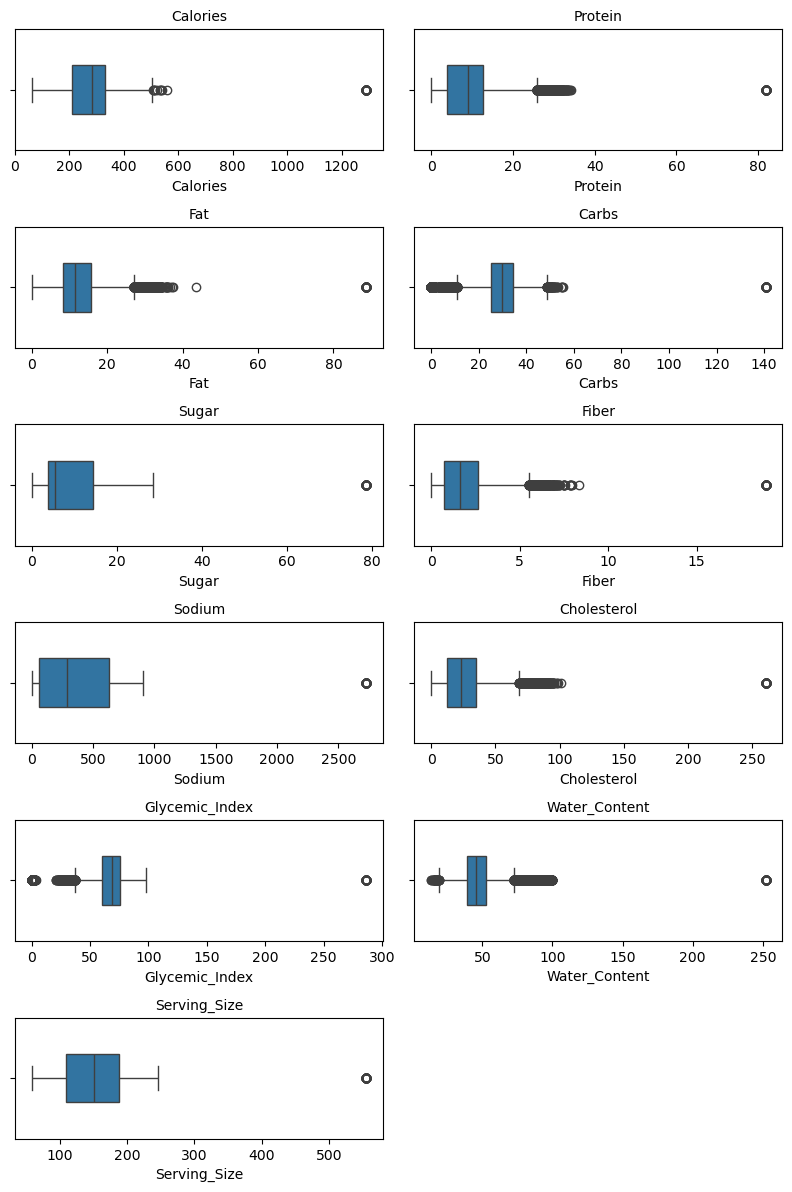

In [25]:
rows = (len(num_cols) + 1) // 2
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(8, 2*rows))  # smaller size

for i, col in enumerate(num_cols):
    r, c = divmod(i, 2)
    sns.boxplot(x=df[col], ax=axes[r][c], width=0.4)  # narrower boxes
    axes[r][c].set_title(f"{col}", fontsize=10)

# Hide empty subplot if odd number of columns
if len(num_cols) % 2 != 0:
    axes[-1][-1].axis("off")

plt.tight_layout(pad=1.0)  # tighter spacing
plt.show()


In [29]:
df.loc[:, col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)


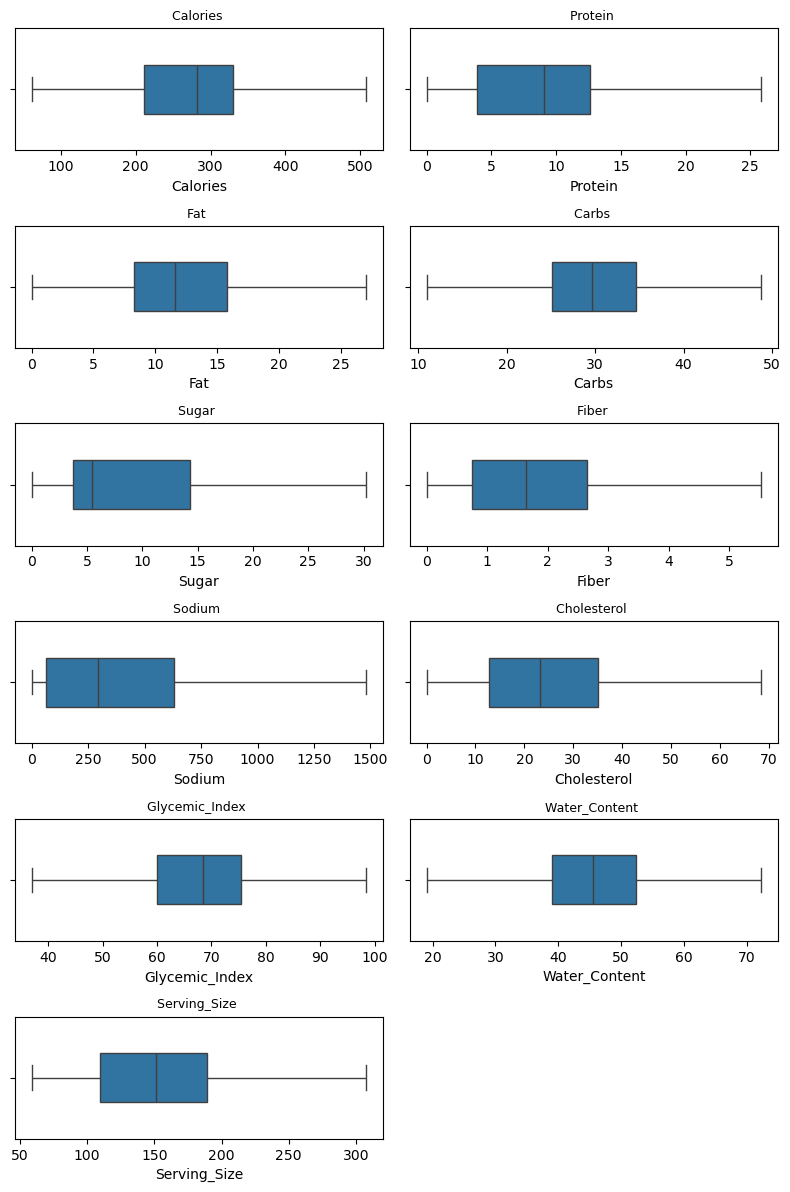

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

rows = (len(num_cols) + 1) // 2   # 2 plots per row
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(8, 2*rows))  # smaller size

for i, col in enumerate(num_cols):
    r, c = divmod(i, 2)
    sns.boxplot(x=df[col], ax=axes[r][c], width=0.4)  # slimmer boxes
    axes[r][c].set_title(f"{col} ", fontsize=9)

# Hide empty subplot if odd number of columns
if len(num_cols) % 2 != 0:
    axes[-1][-1].axis("off")

plt.tight_layout(pad=1.0)
plt.show()


### Encoding

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Make sure df is a copy if it came from a slice
df = df.copy()

# Use .loc for explicit assignment
df.loc[:, "Food_Encoded"] = le.fit_transform(df["Food_Name"])

FEATURE_COLUMNS = num_cols.copy()
X = df[FEATURE_COLUMNS].astype(float)
y = df["Food_Encoded"]


In [32]:
from sklearn.preprocessing import LabelEncoder

le_meal = LabelEncoder()
le_prep = LabelEncoder()

df['Meal_Type'] = le_meal.fit_transform(df['Meal_Type'])
df['Preparation_Method'] = le_prep.fit_transform(df['Preparation_Method'])

In [33]:
df

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name,Food_Encoded
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,1,1,False,False,Pizza,6
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,3,3,False,True,Ice Cream,4
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,3,3,False,False,Burger,2
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,2,1,False,True,Sushi,9
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,3,0,False,False,Donut,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31695,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.275283,120.293342,2,1,True,True,Banana,1
31696,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,192.062481,2,3,False,False,Pizza,6
31697,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,197.318164,0,2,False,False,Pizza,6
31698,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,152.072098,1,2,False,False,Pasta,5


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31387 entries, 0 to 31699
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31387 non-null  float64
 1   Protein             31387 non-null  float64
 2   Fat                 31387 non-null  float64
 3   Carbs               31387 non-null  float64
 4   Sugar               31387 non-null  float64
 5   Fiber               31387 non-null  float64
 6   Sodium              31387 non-null  float64
 7   Cholesterol         31387 non-null  float64
 8   Glycemic_Index      31387 non-null  float64
 9   Water_Content       31387 non-null  float64
 10  Serving_Size        31387 non-null  float64
 11  Meal_Type           31387 non-null  int64  
 12  Preparation_Method  31387 non-null  int64  
 13  Is_Vegan            31387 non-null  bool   
 14  Is_Gluten_Free      31387 non-null  bool   
 15  Food_Name           31387 non-null  object 
 16  Food_Enco

### Feature Scaling

In [41]:
# SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
# Set Random State for Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [43]:
# TRAIN–TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

In [44]:
# ---------- SMOTE ----------
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print(" imblearn not installed. Using class_weight only.")

In [46]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split the dataset first
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Apply SMOTE only on the training set
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


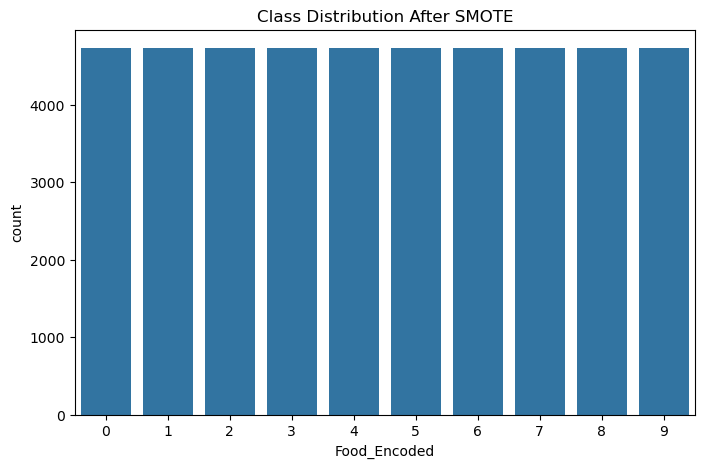

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x=y_train_resampled)   # use y_train_resampled after SMOTE
plt.title("Class Distribution After SMOTE")
plt.show()


In [48]:
# MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}
results = []
trained_models = {}

In [50]:
# TRAIN & EVALUATE
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1_Score": f1
    })

    print(f"\n{name}")
    print(f"Accuracy: {acc:.3f} | Macro F1: {f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
Accuracy: 0.990 | Macro F1: 0.987
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       297
           1       0.97      0.95      0.96       239
           2       0.99      0.99      0.99       988
           3       1.00      1.00      1.00       893
           4       1.00      1.00      1.00       594
           5       1.00      0.99      1.00       795
           6       1.00      0.99      0.99      1183
           7       0.99      0.99      0.99       199
           8       1.00      1.00      1.00       398
           9       0.97      1.00      0.98       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278


Decision Tree
Accuracy: 0.987 | Macro F1: 0.984
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       297
           1       0.99     

In [51]:
# MODEL COMPARISON: ACCURACY + F1 SCORE (SINGLE PLOT)
# Create DataFrame
results_df = pd.DataFrame(results)
# Melt for seaborn
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1_Score"],
    var_name="Metric",
    value_name="Score"
)
# Best model based on F1-score
best_model = results_df.loc[results_df["F1_Score"].idxmax(), "Model"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=results_melted, x="Score", y="Model", hue="Metric")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

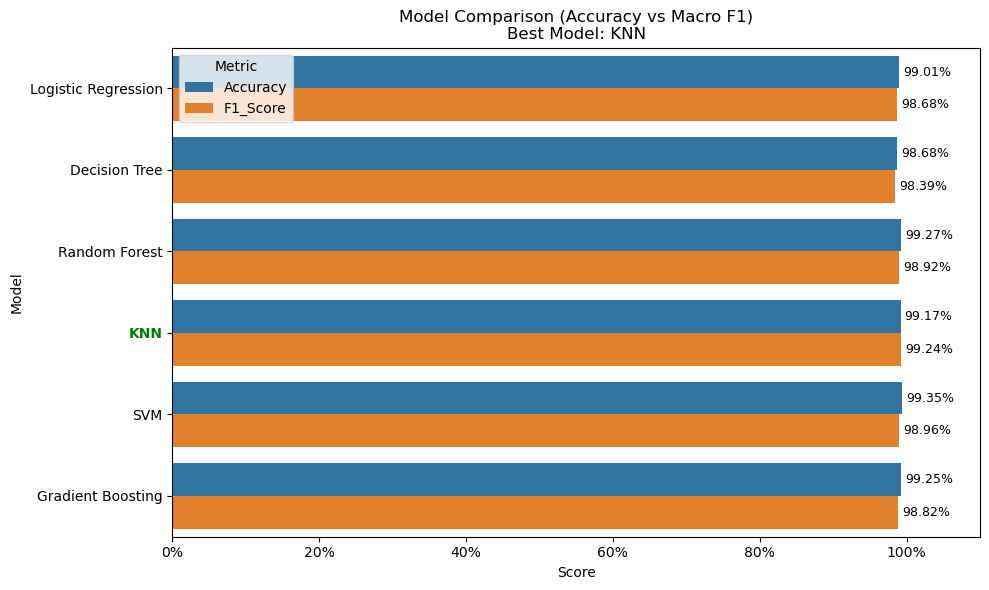

In [52]:
# ADD VALUE LABELS (FIXED)
for container in ax.containers:
    labels = [f"{v*100:.2f}%" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )


# Highlight best model label
for label in ax.get_yticklabels():
    if label.get_text() == best_model:
        label.set_color("green")
        label.set_fontweight("bold")

# Title & axes
plt.title(f"Model Comparison (Accuracy vs Macro F1)\nBest Model: {best_model}")
plt.xlabel("Score")
plt.xlim(0, 1.10)
plt.ylabel("Model")

plt.legend(title="Metric")
plt.tight_layout()

plt.show(block=False)

In [53]:
# BEST MODEL
best_model_name = results_df.loc[
    results_df["F1_Score"].idxmax(),
    "Model"
]
best_model = trained_models[best_model_name]

print("\n Best Model Selected:", best_model_name)


 Best Model Selected: KNN


In [54]:
# Save Trained NutriClass Model and Preprocessing Artifacts
joblib.dump(best_model, "Nutriclass_Training_model.pkl")
joblib.dump(scaler, "Nutriclass_Training_scaler.pkl")
joblib.dump(le, "Nutriclass_Training_label_encoder.pkl")
joblib.dump(FEATURE_COLUMNS, "Nutriclass_Training_features.pkl")

print(" Model, scaler, encoder, features saved")

 Model, scaler, encoder, features saved


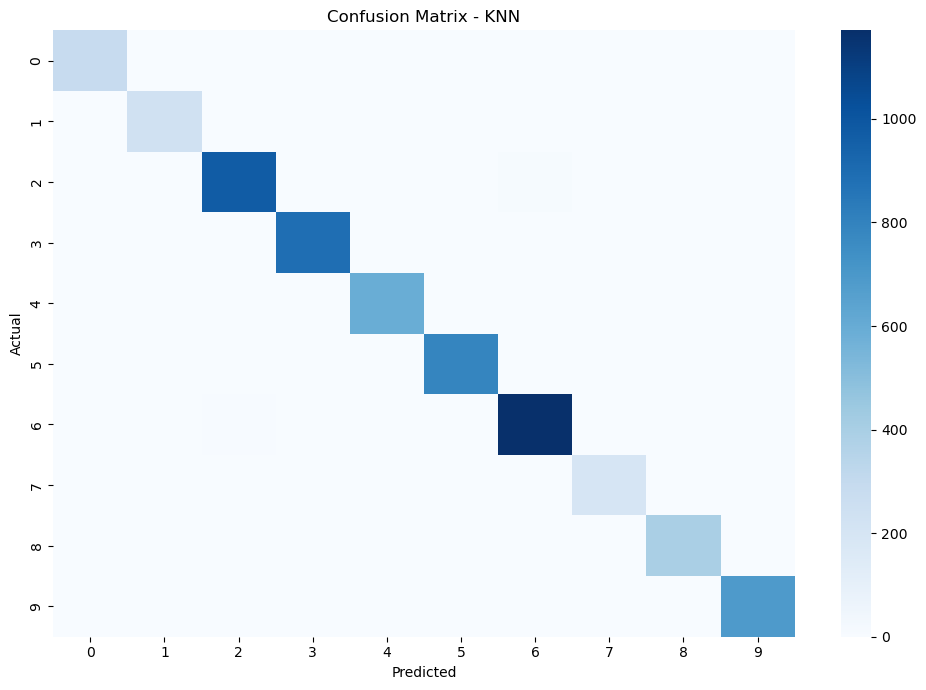

In [55]:
# CONFUSION MATRIX
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show(block=False)

In [56]:
# REAL-TIME PREDICTION FUNCTION
def predict_food(nutrition_input: dict):
    input_df = pd.DataFrame(
        [np.nan] * len(FEATURE_COLUMNS),
        index=FEATURE_COLUMNS
    ).T

    for key, value in nutrition_input.items():
        if key in input_df.columns:
            input_df.loc[0, key] = float(value)

    # Fill missing values with 0 (or training median if you saved it)
    input_df = input_df.fillna(0)

    input_scaled = scaler.transform(input_df)
    pred = best_model.predict(input_scaled)

    return le.inverse_transform(pred)[0]

In [57]:
# SAMPLE PREDICTION
sample_input = {
    "Calories": 116.441715,
    "Protein": 0.513997326,
    "Fat": 0.541772206,
    "Carbs": 23.33647735,
    "Sugar": 18.43439593
}
print("\n Predicted Food:", predict_food(sample_input))


 Predicted Food: Ice Cream


In [58]:
# Take the first row of your dataset
first_row = df.iloc[1][FEATURE_COLUMNS]

# Convert to dictionary
nutrition_input = first_row.to_dict()

# Run prediction
result = predict_food(nutrition_input)

print("Input row:\n", nutrition_input)
print("Predicted Food:", result)


Input row:
 {'Calories': 212.6267481130054, 'Protein': 4.080907886630317, 'Fat': 11.621583825141595, 'Carbs': 23.21895662182417, 'Sugar': 16.347814205204134, 'Fiber': 0.1303034214124855, 'Sodium': 68.57241407856299, 'Cholesterol': 34.301652263407185, 'Glycemic_Index': 69.52249230111168, 'Water_Content': 49.85441535230896, 'Serving_Size': 103.83350985259533}
Predicted Food: Ice Cream
